# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 4.20s
Prepared 45 packages in 55.10s
Uninstalled 23 packages in 876ms
Installed 45 packages in 478ms
 - click==8.3.3
 + click==8.1.8
 + cyclopts==4.13.0
 - decorator==4.4.2
 + decorator==5.2.1
 + exca==0.5.25
 + gtts==2.5.4
 + julius==0.2.7
 + langdetect==1.0.9
 + levenshtein==0.27.3
 + lightning-utilities==0.15.3
 + mne==1.12.1
 + mne-bids==0.18.0
 - moviepy==1.0.3
 + moviepy==2.2.1
 + neuralset==0.0.2
 + neuraltrain==0.0.2
 + nilearn==0.13.1
 - numpy==2.0.2
 + numpy==2.2.6
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-cur

## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [1]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-17 06:59:31 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-17 06:59:46 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [2]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/sample_video.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [02:59<00:00, 179.66s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 30/30 [00:00<00:00, 67144.67it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,52.210000,cache/sample_video.wav,NaN,
1,Video,0.000000,52.210000,cache/sample_video.mp4,NaN,
2,Sentence,12.212999,2.042002,NaN,What brings you to the land of the gatekeepers?.,
3,Text,12.213000,31.490000,NaN,What brings you to the land of the gatekeepers...,
4,Word,12.213000,0.120000,NaN,What,What
5,Word,12.393000,0.280000,NaN,brings,What brings
6,Word,12.713000,0.101000,NaN,you,What brings you
7,Word,12.854000,0.100000,NaN,to,What brings you to


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [3]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[07:05:37 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-05-17 07:10:44 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
Encoding video:   0%|          | 0/104 [00:00<?, ?it/s]2026-05-17 07:11:01 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (104, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (104, 20, 1408)
Encoding video: 100%|██████████| 104/104 [27:35<00:00, 15.92s/it]
[07:38:20 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-17 07:38:20 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[07:38:20 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: 

Predictions shape: (53, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:04<00:00,  3.54it/s]


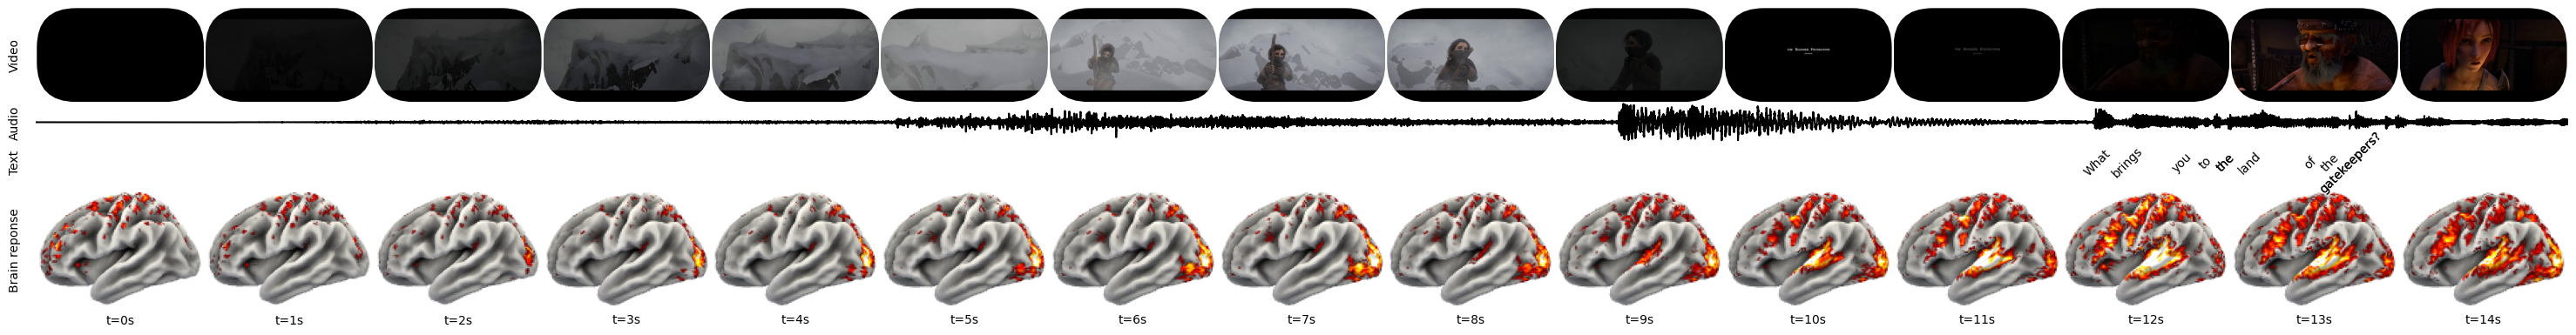

In [4]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

## Modifikasi: Input Berupa Beberapa Screenshot

Jika Anda memiliki beberapa screenshot, kita bisa menggabungkannya menjadi satu file video agar bisa diproses oleh model TRIBE v2.

In [5]:
import numpy as np
from PIL import Image
from moviepy import ImageSequenceClip
import os

# 1. Menyiapkan folder untuk screenshot
screenshot_dir = CACHE_FOLDER / "screenshots"
os.makedirs(screenshot_dir, exist_ok=True)

# 2. Contoh: Membuat 3 gambar dummy (Ganti bagian ini dengan upload file Anda sendiri)
# Misal: screenshot_paths = ["gambar1.png", "gambar2.png", ...]
img_paths = []
for i in range(3):
    img_data = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
    img = Image.fromarray(img_data)
    path = screenshot_dir / f"ss_{i}.png"
    img.save(path)
    img_paths.append(str(path))

# 3. Menggabungkan screenshot menjadi video (misal: tiap gambar tampil selama 2 detik)
fps = 1
duration_per_img = 2
video_from_ss_path = CACHE_FOLDER / "from_screenshots.mp4"

# Ulangi list gambar agar durasi tercapai
clip_images = []
for p in img_paths:
    clip_images.extend([p] * (duration_per_img * fps))

clip = ImageSequenceClip(clip_images, fps=fps)
clip.write_videofile(str(video_from_ss_path), codec="libx264", audio=False)

# 4. Proses dengan model
df_ss = model.get_events_dataframe(video_path=video_from_ss_path)
preds_ss, segments_ss = model.predict(events=df_ss)

print(f"Predictions shape from screenshots: {preds_ss.shape}")

MoviePy - Building video cache/from_screenshots.mp4.
MoviePy - Writing video cache/from_screenshots.mp4



MoviePy - Done !
MoviePy - video ready cache/from_screenshots.mp4


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  8.14it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-05-17 07:47:34 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-05-17 07:47:34 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[07:47:34 WARNING] Removing extractor audio as there are no corresponding events
[07:47:34 WARNING] Removing extractor text as there are no corresponding events
[07:47:34 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-05-17 07:47:45 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 6.0s at 1.0fps, shape (640, 480)):
cache/from_screenshots.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 6.0s at 1.0fps, shape (640, 480)):
cache/from_screenshots.mp4
Encoding video:   0%|          | 0/12 [00:00<?, ?it/s]2026-05-17 07:48:02 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (12, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (12, 20, 1408)
Encoding video: 100%|██████████| 12/12 [03:04<00:00, 15.41s/it]
[07:50:51 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-17 07:50:51 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[07:50:51 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: Thi

Predictions shape from screenshots: (6, 20484)


Plotting...: 100%|██████████| 6/6 [00:01<00:00,  3.25it/s]


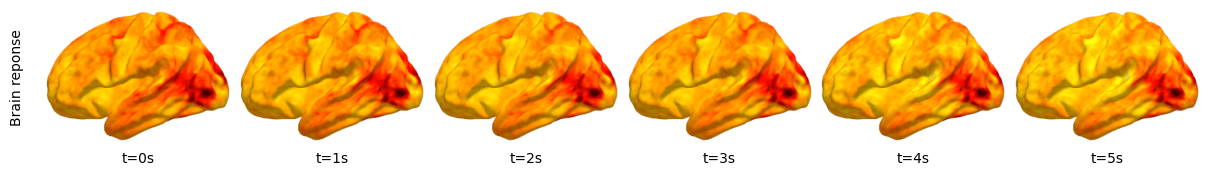

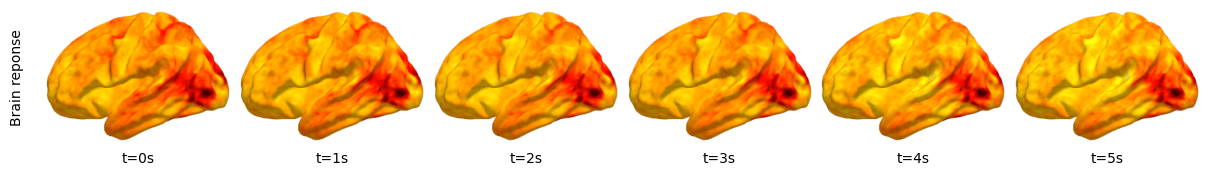

In [7]:
# 5. Visualisasi hasil dari screenshot
# Karena video dari screenshot tidak punya audio, kita matikan show_stimuli
# atau kita bisa tetap menggunakannya dengan memastikan model tahu tidak ada audio.
plotter.plot_timesteps(
    preds_ss,
    segments=segments_ss,
    cmap="fire",
    show_stimuli=False  # Diubah ke False karena tidak ada track audio untuk divisualisasikan
)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [ ]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [ ]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)